In [127]:
import numpy as np
import scipy as sp
import cv2
import os

In [128]:
def load_images(path, size=(100,100)):
    images = []
    labels = []
    label = 0
    
    for person in os.listdir(path):
        person_path = os.path.join(path, person)
        if os.path.isdir(person_path):
            for img_name in os.listdir(person_path):
                img_path = os.path.join(person_path, img_name)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, size)
                img = img.flatten()
                images.append(img)
                labels.append(label)
            label += 1
    
    return np.array(images).T, np.array(labels)

We use .T because the assignment requires the face database to be:(mn×p)
where:
mn = number of pixels
p = number of images
each column = one face image

In [129]:
def compute_mean(face_db):
    mean_face = np.mean(face_db, axis=1).reshape(-1,1)
    return mean_face

In [130]:
def mean_zero(face_db, mean_face):
    return face_db - mean_face

In [131]:
def surrogate_covariance(delta):
    return np.dot(delta.T, delta)   # ✅ (448 × 448) FAST

#PCA STARTS NOW

In [132]:
def compute_eigen(cov_matrix):
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    idx = np.argsort(-eigenvalues)
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    return eigenvalues, eigenvectors

In [133]:
def select_k(eigenvectors, k):
    return eigenvectors[:, :k] ##top k features are gonna be selected !!

In [134]:
def generate_eigenfaces(delta, eigenvectors_k):
    # delta: (10000, 448)
    # eigenvectors_k: (448, k)

    eigenfaces = np.dot(delta, eigenvectors_k)   # ✅ (10000, k)

    # normalize
    eigenfaces = eigenfaces / np.linalg.norm(eigenfaces, axis=0)

    return eigenfaces

In [135]:
def generate_signatures(eigenfaces, delta):
    return np.dot(eigenfaces.T, delta)   # ✅ CORRECT

In [136]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


from sklearn.preprocessing import StandardScaler

def train_ann(features, labels):
    X = features.T

    X_train, X_test, y_train, y_test = train_test_split(
        X, labels, test_size=0.2, stratify=labels, random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)   # ✅ only train
    X_test  = scaler.transform(X_test)        # ✅ only transform test

    clf = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=1000,
        activation='relu',
        solver='adam',
        random_state=42
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    return acc

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


k = 5, Accuracy = 0.5111111111111111
k = 10, Accuracy = 0.4666666666666667
k = 20, Accuracy = 0.5666666666666667
k = 30, Accuracy = 0.6555555555555556
k = 40, Accuracy = 0.6333333333333333
k = 50, Accuracy = 0.6666666666666666
k = 60, Accuracy = 0.7222222222222222
k = 70, Accuracy = 0.6777777777777778
k = 80, Accuracy = 0.6888888888888889
k = 90, Accuracy = 0.6555555555555556
k = 100, Accuracy = 0.6666666666666666


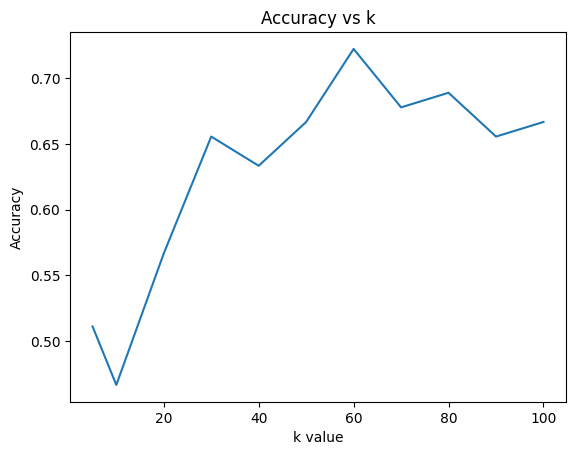

In [137]:
def main():

    path = "C:/Users/Admin/OneDrive/Desktop/faces"

    face_db, labels = load_images(path)

    mean_face = compute_mean(face_db)
    delta = mean_zero(face_db, mean_face)
    C = surrogate_covariance(delta)

    eigenvalues, eigenvectors = compute_eigen(C)

    k_values = [5, 10, 20, 30, 40, 50,60,70,80,90,100]
    accuracies = []

    for k in k_values:

        eigenvectors_k = select_k(eigenvectors, k)
        eigenfaces = generate_eigenfaces(delta, eigenvectors_k)
        signatures = generate_signatures(eigenfaces, delta)

        acc = train_ann(signatures, labels)

        accuracies.append(acc)
        print(f"k = {k}, Accuracy = {acc}")

    # Plot AFTER loop
    import matplotlib.pyplot as plt
    plt.plot(k_values, accuracies)
    plt.xlabel("k value")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs k")
    plt.show()


if __name__ == "__main__":
    main()


before impostering

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


k = 5, Accuracy = 0.5111111111111111
k = 10, Accuracy = 0.4666666666666667
k = 20, Accuracy = 0.5666666666666667
k = 30, Accuracy = 0.6555555555555556
k = 40, Accuracy = 0.6333333333333333
k = 50, Accuracy = 0.6666666666666666
k = 60, Accuracy = 0.7222222222222222
k = 70, Accuracy = 0.6777777777777778
k = 80, Accuracy = 0.6888888888888889
k = 90, Accuracy = 0.6555555555555556
k = 100, Accuracy = 0.6666666666666666


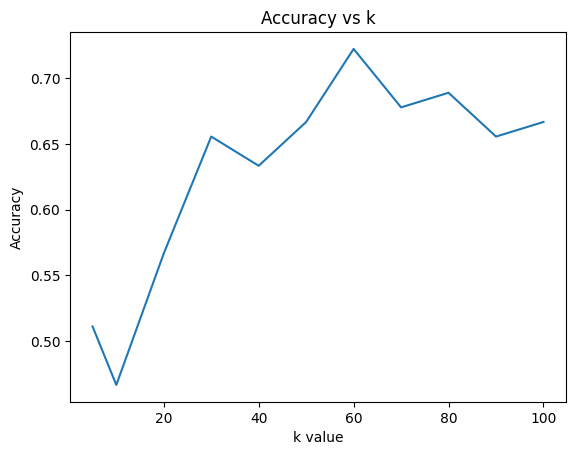

In [138]:
def main():

    path = "C:/Users/Admin/OneDrive/Desktop/faces"

    face_db, labels = load_images(path)

    mean_face = compute_mean(face_db)
    delta = mean_zero(face_db, mean_face)
    C = surrogate_covariance(delta)

    eigenvalues, eigenvectors = compute_eigen(C)

    k_values = [5, 10, 20, 30, 40, 50,60,70,80,90,100]
    accuracies = []

    for k in k_values:

        eigenvectors_k = select_k(eigenvectors, k)
        eigenfaces = generate_eigenfaces(delta, eigenvectors_k)
        signatures = generate_signatures(eigenfaces, delta)

        acc = train_ann(signatures, labels)

        accuracies.append(acc)
        print(f"k = {k}, Accuracy = {acc}")

    # Plot AFTER loop
    import matplotlib.pyplot as plt
    plt.plot(k_values, accuracies)
    plt.xlabel("k value")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs k")
    plt.show()


if __name__ == "__main__":
    main()



AS THE IMPOSTERS INCREASE THE PEAK SHIFT TOWARDS RIGHT?
When imposters increase:

1️⃣ Small k is not enough
→ Too little identity information
→ Faces look similar in compressed space
→ ANN confuses them

2️⃣ Higher k keeps more detailed facial features
→ Better separation between identities
→ Better detection of unknown faces

So optimal k increases.

In [139]:
# ── NEW: Predict person from uploaded photo ──────────────────────────────
# Run this cell AFTER the k-value search above.
# It picks the best k found, retrains on ALL data, then lets you upload
# a photo and prints the predicted person's name.

import os
import cv2
import numpy as np
from sklearn.neural_network import MLPClassifier
from ipywidgets import FileUpload, Output, Button, VBox
from IPython.display import display, clear_output
import ipywidgets as widgets

# ── Step 1: Build person-name mapping from your dataset path ─────────────
DATASET_PATH = "C:/Users/Admin/OneDrive/Desktop/faces"  # same as above
IMG_SIZE = (100, 100)
BEST_K = 80  # change this to whatever k gave the best accuracy above

def build_name_map(path):
    """Returns a dict {label_int: folder_name} from the dataset directory."""
    name_map = {}
    label = 0
    for person in sorted(os.listdir(path)):
        if os.path.isdir(os.path.join(path, person)):
            name_map[label] = person
            label += 1
    return name_map

# ── Step 2: Train final model on ALL data with best k ────────────────────
print("Training final model on all data with k =", BEST_K, "...")

_face_db, _labels = load_images(DATASET_PATH, IMG_SIZE)
_name_map = build_name_map(DATASET_PATH)

_mean_face   = compute_mean(_face_db)
_delta       = mean_zero(_face_db, _mean_face)
_C           = surrogate_covariance(_delta)
_, _evecs    = compute_eigen(_C)
_evecs_k     = select_k(_evecs, BEST_K)
_eigenfaces  = generate_eigenfaces(_delta, _evecs_k)
_signatures  = generate_signatures(_eigenfaces, _delta)

_clf = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500,
                     activation='relu', solver='adam', random_state=42)
_clf.fit(_signatures.T, _labels)
print("Model ready!")

# ── Step 3: Widget – upload a photo and get the name ─────────────────────
def predict_face(image_bytes):
    """Given raw image bytes, return the predicted person name."""
    arr = np.frombuffer(image_bytes, dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE).flatten().reshape(-1, 1)
    img_centered = img - _mean_face
    signature    = np.dot(_eigenfaces.T, img_centered)  # (k, 1)
    label_pred   = _clf.predict(signature.T)[0]
    return _name_map.get(label_pred, f"Unknown (label {label_pred})")

upload   = FileUpload(accept='image/*', multiple=False, description='Upload face')
out      = Output()
btn      = Button(description='Identify Person', button_style='primary')

def on_click(_):
    with out:
        clear_output()
        if not upload.value:
            print('Please upload an image first.')
            return
        # Handle both ipywidgets v7 (tuple) and v8+ (dict)
        item = upload.value[0] if isinstance(upload.value, tuple) else list(upload.value.values())[0]
        raw  = item['content'] if isinstance(item, dict) else item.content
        name = predict_face(bytes(raw))
        print(f'Predicted person: {name}')

btn.on_click(on_click)
display(VBox([upload, btn, out]))


Training final model on all data with k = 80 ...
Model ready!
